## Kepler's Third Law of Planetary

In [1]:
from d2l import torch as d2l
import torch
import numpy as np
import matplotlib.pyplot as plt

### 1. Training

#### 1.1 Preprogress of data

In [2]:
d = torch.tensor([0.387, 0.723, 1.000, 1.523, 5.203, 9.541, 19.190, 30.086]).reshape(-1, 1)
T = torch.tensor([0.241, 0.615, 1.000, 1.881, 11.861, 29.457, 84.008, 164.784]).reshape(-1, 1)

X = torch.log(d)
y = torch.log(T)

#### 1.2 Analytic Solution &ensp;<font size=2>*Normal Equation*

In [3]:
# 在X末尾添加一列1，以最终解得联合参数(w, b)
X_expend = torch.cat((X, torch.ones(X.shape[0], 1)), dim=1)
w, b = np.linalg.solve(X_expend.T @ X_expend, X_expend.T @ y)
w, b

(array([1.4995288], dtype=float32), array([0.00043123], dtype=float32))

$$log(T) = wlog(d) + b $$     
$$ T = e^bd^w $$

#### 1.3 Minibatch Stochastic Gradient Descent

In [4]:
class PlanetaryMotionRegressionData(d2l.DataModule):
    """Planet's data to fit Kepler's Third Law of PLanetary Motion."""
    def __init__(self, d, T, batch_size=4, num_train=6):       
        super().__init__()
        self.save_hyperparameters()
        self.X = torch.log(d)
        self.y = torch.log(T)

    def get_tensorloader(self, tensors, train, indices=slice(0, None)):
        tensors = tuple(a[indices] for a in tensors)
        dataset = torch.utils.data.TensorDataset(*tensors)
        return torch.utils.data.DataLoader(dataset, self.batch_size, shuffle=train)

    def get_dataloader(self, train):
        i = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader((self.X, self.y), train, i)

再摸索下随机样本的问题…   
按理说```shuffle=train```的时候应该会随机抽取样本吧……    

In [5]:
data = PlanetaryMotionRegressionData(d, T)

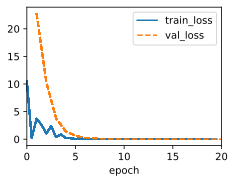

In [6]:
model = d2l.LinearRegression(lr=0.05)  
trainer = d2l.Trainer(max_epochs=20)
trainer.fit(model, data)

In [7]:
weight, bias = model.get_w_b()
weight, bias

(tensor([[1.4969]]), tensor([0.0047]))

Similarly,    
$$log(T) = weight \times log(d) + bias$$    
$$T = e^{bias} \times d^{weight}$$

#### 1.4 Visualization

In [8]:
x_vals = np.linspace(data.X[0].item(), data.X[-1].item(), 100)
# Normal Equation
y_NE = (w * x_vals).reshape(x_vals.shape)
# Minibatch SGD
y_SGD = (weight.numpy() * x_vals + bias.numpy()).reshape(x_vals.shape)

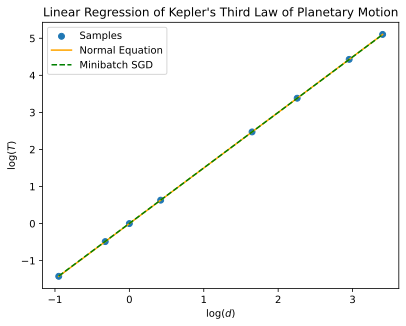

In [9]:
plt.scatter(data.X.numpy(), data.y.numpy(), label='Samples')
plt.plot(x_vals, y_NE, label='Normal Equation', color='orange')
plt.plot(x_vals, y_SGD, label='Minibatch SGD', color='green', linestyle='--')
plt.xlabel('log($d$)')
plt.ylabel('log($T$)')
plt.title("Linear Regression of Kepler's Third Law of Planetary Motion")
plt.legend()
plt.show()

### 2. Testing &ensp;<font size=2>*On Minibatch SGD*

#### 2.1 Predict by forward methord

In [10]:
@d2l.add_to_class(d2l.LinearRegression)
def test_and_show(self, d_test):
    """Print out prediction and visualize it."""
    d_test = d_test.reshape(-1, 1)
    self.X_test = torch.log(d_test)
    #self.y_test = model.forward(self.X_test)
    self.y_test = model(self.X_test)
    self.T_test = torch.exp(self.y_test)      # which is the final result
    print(f"The T of Ceres is {self.T_test[0].item():.3f}.")
    print(f"The T of Pluto is {self.T_test[-1].item():.3f}.")

@d2l.add_to_class(d2l.LinearRegression)
def get_X_y_test(self):
    return self.X_test, self.y_test

In [11]:
dir(d2l.LinearRegression)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_call_impl',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_load_from_state_dict',
 '_maybe_warn_non_full_backward_hook',
 '_named_members',
 '_register_load_state_dict_pre_hook',
 '_register_state_dict_hook',
 '_replicate_for_data_parallel',
 '_save_to_state_dict',
 '_slow_forward',
 '_version',
 'add_module',
 'apply',
 'apply_init',
 'bfloat16',
 'buffers',
 'call_super_init',
 'children',
 'configure_optimizers',
 'cpu',
 'cuda',
 'double',
 'dump_patches',
 'eval',
 'extra_repr',
 'float',
 'forward',

也许是```__call__```内调用了```forward()```…   
但其实翻到的```__call__```的定义并看不太懂（

In [12]:
d_test = torch.tensor([2.77, 39.5])
model.test_and_show(d_test)

The T of Ceres is 4.617.
The T of Pluto is 246.610.


#### 2.2 Visualization

In [13]:
X_test, y_test = model.get_X_y_test()
x_total = torch.cat((data.X, X_test), dim=0).detach().numpy()
y_total = torch.cat((data.y, y_test), dim=0).detach().numpy()

x_total.sort(axis=0)
y_total.sort(axis=0)

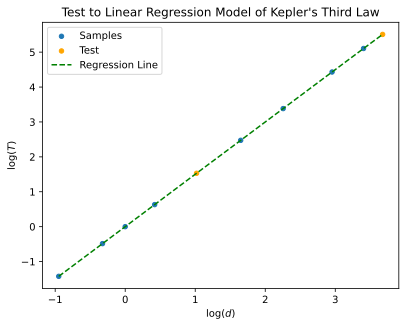

In [14]:
plt.scatter(data.X.numpy(), data.y.numpy(), label='Samples', s=20)
plt.scatter(X_test.detach().numpy(), y_test.detach().numpy(), label='Test', color='orange', s=20)
plt.plot(x_total, y_total, label="Regression Line", color='green', linestyle='--')
plt.xlabel('log($d$)')
plt.ylabel('log($T$)')
plt.title("Test to Linear Regression Model of Kepler's Third Law")
plt.legend()
plt.show()

### 3. Save results in .txt file

In [15]:
def format_result(item):
    if isinstance(item, float):
        item = f"{item: .3f}"
    return f"{item:<{8}}"

In [16]:
def format_results(names, labels, d, T):
    T = T.reshape(-1, 1)
    result_data = torch.cat((d.reshape(-1, 1), T), dim=1).tolist()
    results = labels + [(names[0] + result_data[0])] + [(names[-1] + result_data[-1])]
    formatted_results = []
    for result in results:
        for rslt in result:
            formatted_results.append(format_result(rslt))
        formatted_results.append("\n")
    return formatted_results

In [17]:
names = [["Ceres"], ["Pluto"]]
labels = [["Planet", "d", "T"]]
T_test = model.T_test

results = format_results(names, labels, d_test, T_test)

In [18]:
with open("KeplersThirdLaw.txt", "w") as file:
    for line in results:
        file.write(line)